<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week8_Day2_Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installation forcée et redémarrage automatique du kernel pour appliquer les changements
!pip install --force-reinstall -qU langgraph langchain-google-genai google-genai

import os
# Cette commande force le redémarrage du kernel Colab immédiatement
os._exit(0)

^C


In [6]:
import os
from google.colab import userdata

# Assurez-vous d'avoir ajouté 'GOOGLE_API_KEY' dans l'onglet Secret (icône clé 🔑)
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

### 3. Définition des instructions de base et de l'état
Nous définissons ici l'objet `OrderState` qui suivra l'historique de la conversation, le contenu de la commande et si celle-ci est terminée.

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class OrderState(TypedDict):
    """État représentant la conversation de commande du client."""
    # Historique des messages (add_messages permet d'ajouter au lieu de remplacer)
    messages: Annotated[list, add_messages]
    # Liste des articles commandés
    order: list[str]
    # Indicateur de fin de commande
    finished: bool

# Instructions système pour BaristaBot
BARISTABOT_SYSINT = (
    "system",
    "You are a BaristaBot, an interactive cafe ordering system. A human will talk to you about the "
    "available products you have and you will answer any questions about menu items. "
    "Add items to the customer's order with add_to_order, and reset the order with clear_order. "
    "Always confirm_order with the user before calling place_order. "
    "Once the customer has finished ordering items, Call confirm_order, then place_order, thank the user and say goodbye!",
)

WELCOME_MSG = "Welcome to the BaristaBot cafe. Type `q` to quit. How may I serve you today?"

print("État et instructions système définis avec succès.")

État et instructions système définis avec succès.


/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### 4. Définir un chatbot à tour unique
Cette section configure le modèle LLM et définit le premier nœud de notre graphe.

In [37]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage
import os

# Basculement vers gemini-flash-latest pour contourner l'erreur de quota 429
selected_model = "models/gemini-flash-latest"
llm = ChatGoogleGenerativeAI(model=selected_model)

def chatbot(state: OrderState) -> OrderState:
    """Le chatbot : un simple wrapper autour de l'interface de chat du modèle."""
    sys_msg = SystemMessage(content=BARISTABOT_SYSINT[1])
    message_history = [sys_msg] + state["messages"]
    response = llm.invoke(message_history)
    return {"messages": [response]}

# Reconstruction du graphe
graph_builder = StateGraph(OrderState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
chat_graph = graph_builder.compile()

print(f"Graphe reconfiguré sur {selected_model} pour éviter les limites de quota.")

Graphe reconfiguré sur models/gemini-flash-latest pour éviter les limites de quota.


### 5. Visualisation du graphe
Utilisons Mermaid pour afficher la structure actuelle de notre application.

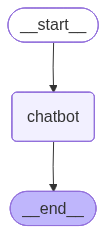

In [9]:
from IPython.display import Image, display

try:
    display(Image(chat_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"La visualisation a échoué (nécessite pygraphviz ou mermaid.ink) : {e}")

### 6. Exécution du graphe
Testons une invocation simple avec un message de l'utilisateur.

In [38]:
from langchain_core.messages import HumanMessage, AIMessage
import time

# Pause de sécurité pour le quota
time.sleep(2)

user_msg = HumanMessage(content="Bonjour, quels sont les cafés disponibles ?")
initial_state = {"messages": [user_msg], "order": [], "finished": False}

try:
    print(f"Appel du modèle {selected_model}...")
    # Utilisation du graphe compilé avec le modèle sélectionné
    final_state = chat_graph.invoke(initial_state)
    for msg in final_state['messages']:
        role = "Bot" if isinstance(msg, AIMessage) else "Humain"
        print(f"{role}: {msg.content}")
except Exception as e:
    print(f"Erreur lors de l'invocation : {e}")

Appel du modèle models/gemini-flash-latest...
Humain: Bonjour, quels sont les cafés disponibles ?
Bot: [{'type': 'text', 'text': "Bonjour ! Bienvenue au BaristaBot. ☕\n\nVoici les cafés que nous proposons :\n\n*   **Espresso** (serré et intense)\n*   **Double Espresso** (pour un double boost d'énergie)\n*   **Allongé / Americano** (un espresso adouci avec de l'eau chaude)\n*   **Cappuccino** (un espresso avec du lait chaud et une belle mousse de lait)\n*   **Café Latte** (très crémeux, beaucoup de lait chaud et un peu de mousse)\n*   **Macchiato** (un espresso avec juste une touche de mousse de lait)\n\nQu'est-ce qui vous ferait plaisir aujourd'hui ?", 'extras': {'signature': 'EvsKCvgKARFNMg84MYT0IkIpYzvYaSRTHqx6wZky+qTrqBrBqxXV8HynEarcCWzoVb8KRo9KS1ASscvAm5GV+2TAsokR4u9oqyKYVX6if6Jcj8xVrtBBS3CiRgK1W3yH94XxvmyPCG9LdRes5EZEdJD/ijjfyHitSRpJ7MK2V+dWf4BWiVsZxxrkL6S0IlB24R/FQ8fBpVlqLNJIeDcIfU3Lr+8MBExNTrPUTFOn3utvrnhzJSL7U/1ZWc0WzftU273yBd9sm5kLiSCEiqBvPbw4XVhMH80OVt2HqqBgJdZanDR3LZSkWjs9Hh

### 7. Ajouter une boucle de conversation
Pour transformer ce chatbot à tour unique en un agent interactif, nous ajoutons un nœud qui capture l'entrée de l'utilisateur.

In [39]:
def human_node(state: OrderState) -> OrderState:
    """Nœud qui simule l'entr9e utilisateur via input()."""
    user_input = input("VOUS (tapez 'q' pour quitter): ")
    return {"messages": [HumanMessage(content=user_input)]}

# Nouveau constructeur pour un graphe avec boucle
smart_builder = StateGraph(OrderState)
smart_builder.add_node("chatbot", chatbot)
smart_builder.add_node("human", human_node)

# On commence par le bot ou l'humain ? Commen1ons par le bot pour l'accueil
smart_builder.add_edge(START, "chatbot")
smart_builder.add_edge("chatbot", "human")
smart_builder.add_edge("human", "chatbot")

# Compilation du graphe interactif
# Note: Nous ajouterons une condition de sortie 'q' plus tard
interactive_graph = smart_builder.compile()
print("Graphe interactif avec human_node cr99.")

Graphe interactif avec human_node cr99.


### 8. Ajouter une condition de sortie et lancer la boucle
Nous utilisons `add_conditional_edges` pour vérifier si l'utilisateur souhaite quitter.

In [41]:
def select_next_node(state: OrderState):
    """Vérifie si le dernier message est 'q' pour arrêter le graphe."""
    if not state["messages"]:
        return "chatbot"
    last_message = state["messages"][-1]
    if hasattr(last_message, 'content') and isinstance(last_message.content, str):
        if last_message.content.lower().strip() == 'q':
            return END
    return "chatbot"

# Reconstruction finale
final_builder = StateGraph(OrderState)
final_builder.add_node("chatbot", chatbot)
final_builder.add_node("human", human_node)

final_builder.add_edge(START, "chatbot")
final_builder.add_edge("chatbot", "human")
final_builder.add_conditional_edges("human", select_next_node)

barista_bot = final_builder.compile()

print("--- Démarrage de BaristaBot (tapez 'q' pour arrêter) ---")

try:
    # On initialise avec un premier message pour éviter l'erreur 'contents are required'
    initial_input = {"messages": [HumanMessage(content="Bonjour !")]}

    # Lancement de l'exécution
    # Note: Dans Colab, l'input() dans une boucle peut être capricieux,
    # cette cellule lancera le premier cycle.
    res = barista_bot.invoke(initial_input)

    # Extraction propre du texte (Gemini renvoie parfois une liste de dicts)
    last_msg_content = res['messages'][-1].content
    if isinstance(last_msg_content, list):
        text_response = next((item['text'] for item in last_msg_content if item.get('type') == 'text'), str(last_msg_content))
    else:
        text_response = last_msg_content

    print(f"\nBot: {text_response}")
except Exception as e:
    print(f"\nFin de session ou erreur : {e}")

--- Démarrage de BaristaBot (tapez 'q' pour arrêter) ---
VOUS (tapez 'q' pour quitter): q

Bot: q


### 9. Intégration des Outils (Tools)
Nous allons définir des fonctions Python que le LLM peut décider d'appeler pour gérer la commande de l'utilisateur.

In [42]:
from langchain_core.tools import tool

@tool
def add_to_order(item: str, state: OrderState):
    """Ajoute un article de café à la commande du client."""
    # Note: Dans LangGraph, les outils peuvent accéder ou modifier l'état
    return {"order": state.get("order", []) + [item]}

@tool
def clear_order(state: OrderState):
    """Efface tous les articles de la commande actuelle."""
    return {"order": []}

tools = [add_to_order, clear_order]
# Lier les outils au modèle
llm_with_tools = llm.bind_tools(tools)

print(f"{len(tools)} outils définis et liés au modèle {selected_model}.")

2 outils définis et liés au modèle models/gemini-flash-latest.


### 10. Nœud d'exécution des outils et logique de routage
Nous utilisons le `ToolNode` prédéfini de LangGraph pour exécuter les outils appelés par le LLM.

In [52]:
import os
import json
from google.colab import userdata
from typing import Annotated, List, Union
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool

os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
llm = ChatGoogleGenerativeAI(model="models/gemini-flash-latest", temperature=0)

def update_order(old_order: List[str], new_order: List[str]) -> List[str]:
    if old_order is None: return new_order or []
    if not new_order: return old_order
    combined = list(old_order)
    for item in new_order:
        if item not in combined: combined.append(item)
    return combined

class OrderState(TypedDict):
    messages: Annotated[list, add_messages]
    order: Annotated[List[str], update_order]
    finished: bool

@tool
def get_menu():
    """Consult the menu to see products and prices."""
    return "Espresso: 2.50€, Muffin: 3.00€, Latte: 4.00€"

@tool
def add_to_order(item: str):
    """Add a specific item to the customer's order."""
    return f"SUCCESS: {item} added."

tools = [get_menu, add_to_order]
llm_with_tools = llm.bind_tools(tools)

def chatbot_with_tools(state: OrderState) -> OrderState:
    sys_msg = SystemMessage(content="You are BaristaBot. Always call 'add_to_order' for EACH item requested individually.")
    response = llm_with_tools.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}

def order_updater_node(state: OrderState) -> dict:
    new_items = []
    messages = state["messages"]

    print(f"[DEBUG] order_updater checking last {len(messages)} messages")

    # Iterate backwards to find the latest tool interactions
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            break # Stop at the last user command

        # Case A: Standard tool calls
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                if tc['name'] == 'add_to_order':
                    item = tc['args'].get('item')
                    if item: new_items.append(item)

        # Case B: Gemini Legacy Function Calls
        if isinstance(msg, AIMessage) and "function_call" in msg.additional_kwargs:
            fk = msg.additional_kwargs["function_call"]
            if fk.get("name") == "add_to_order":
                args = fk.get("arguments")
                if isinstance(args, str):
                    try: args = json.loads(args)
                    except: pass
                if isinstance(args, dict):
                    item = args.get("item")
                    if item: new_items.append(item)

    if new_items:
        unique_items = list(dict.fromkeys(new_items))
        print(f"[DEBUG] Found items to add to state: {unique_items}")
        return {"order": unique_items}

    return {}

def router(state: OrderState):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls: return "tools"
    if isinstance(last_msg, AIMessage) and "function_call" in last_msg.additional_kwargs: return "tools"
    return END

builder = StateGraph(OrderState)
builder.add_node("chatbot", chatbot_with_tools)
builder.add_node("tools", ToolNode(tools))
builder.add_node("order_updater", order_updater_node)

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", router, {"tools": "tools", END: END})
builder.add_edge("tools", "order_updater")
builder.add_edge("order_updater", "chatbot")

barista_bot_final = builder.compile()
print("BaristaBot v6.0 (Simplified Parsing) prêt !")

BaristaBot v6.0 (Simplified Parsing) prêt !


In [54]:
import time

test_input = {
    "messages": [HumanMessage(content="Bonjour ! Quel est le menu ? Ajoute un Espresso et un Muffin.")],
    "order": [],
    "finished": False
}

print("--- Relance du test de validation ---")
try:
    # Petite pause pour limiter les risques de quota 429
    time.sleep(2)
    output = barista_bot_final.invoke(test_input)

    print(f"\nᜢ Articles dtects dans l'tat 'order' : {output.get('order', [])}")

    if len(output.get('order', [])) >= 2:
        print("\n✅ SUCCS : La commande technique a t mise  jour par les outils !")
    else:
        print("\n❌ CHEC : La liste de commande est toujours vide.")
except Exception as e:
    if "429" in str(e):
        print("\n⚠️ ERREUR DE QUOTA (429) : Vous avez dpass la limite de requtes Gemini. Ressayez dans une minute ou vrifiez vos limites sur Google AI Studio.")
    else:
        print(f"\n❌ Erreur imprvue : {e}")

--- Relance du test de validation ---

⚠️ ERREUR DE QUOTA (429) : Vous avez dpass la limite de requtes Gemini. Ressayez dans une minute ou vrifiez vos limites sur Google AI Studio.
